<a href="https://colab.research.google.com/github/disandovalt/MineriaDeDatos/blob/main/Evaluaci%C3%B3n_3_Mineria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Evaluación 3 — Minería de Datos
**Asignatura:** BIY7121 Minería de Datos

**Dataset:** Vehicle Sales Data — Car Prices

**Fuente:** Kaggle — [Vehicle Sales Data](https://www.kaggle.com/datasets/syedanwarafridi/vehicle-sales-data)

**Integrantes:** Diego Sandoval — Johane San Martin

**Fecha:** 30/06/2026



###  De qué se trata el dataset
El dataset tiene más de **558.000 ventas** de autos usados en subastas de Estados Unidos. Cada fila es la venta de un auto e incluye sus características (marca, modelo, tipo de carrocería, kilometraje, estado) y datos de la venta (el precio final y el `mmr`, que es un precio de referencia del mercado).

Nuestro objetivo principal es **adivinar el precio de venta (`sellingprice`)** a partir de las características del auto. Como queremos predecir un número, esto se llama un problema de **regresión**.

Además, con **K-means** agrupamos los autos en grupos parecidos entre sí, para descubrir distintos "tipos" de auto dentro del mercado.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb


from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import silhouette_score

import joblib                                     # NUEVO: para guardar el modelo en .pkl

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# 1. CARGA DE DATOS Y LIMPIEZA

In [3]:
# Cargar el dataset
data_frame = pd.read_csv("/content/sample_data/car_prices.csv", low_memory=False)
data_frame.head(40)

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)
5,2015,Nissan,Altima,2.5 S,Sedan,automatic,1n4al3ap1fn326013,ca,1.0,5554.0,gray,black,enterprise vehicle exchange / tra / rental / t...,15350.0,10900.0,Tue Dec 30 2014 12:00:00 GMT-0800 (PST)
6,2014,BMW,M5,Base,Sedan,automatic,wbsfv9c51ed593089,ca,34.0,14943.0,black,black,the hertz corporation,69000.0,65000.0,Wed Dec 17 2014 12:30:00 GMT-0800 (PST)
7,2014,Chevrolet,Cruze,1LT,Sedan,automatic,1g1pc5sb2e7128460,ca,2.0,28617.0,black,black,enterprise vehicle exchange / tra / rental / t...,11900.0,9800.0,Tue Dec 16 2014 13:00:00 GMT-0800 (PST)
8,2014,Audi,A4,2.0T Premium Plus quattro,Sedan,automatic,wauffafl3en030343,ca,42.0,9557.0,white,black,audi mission viejo,32100.0,32250.0,Thu Dec 18 2014 12:00:00 GMT-0800 (PST)
9,2014,Chevrolet,Camaro,LT,Convertible,automatic,2g1fb3d37e9218789,ca,3.0,4809.0,red,black,d/m auto sales inc,26300.0,17500.0,Tue Jan 20 2015 04:00:00 GMT-0800 (PST)


In [4]:
data_frame.columns

Index(['year', 'make', 'model', 'trim', 'body', 'transmission', 'vin', 'state',
       'condition', 'odometer', 'color', 'interior', 'seller', 'mmr',
       'sellingprice', 'saledate'],
      dtype='object')

In [5]:
data_frame.shape

(558837, 16)

##  Por qué usamos solo una parte de los datos (una muestra)

El archivo completo tiene más de **558.000 filas (casi 88 MB)**, lo que lo hace muy pesado y lento. Y hay un problema más grande: para evaluar K-means, el computador tiene que comparar cada auto con todos los demás. Con tantas filas eso son miles de millones de comparaciones, y Colab se queda sin memoria y se cae.

Por eso tomamos al azar **50.000 autos**. Revisamos que esta muestra se parece al total (los promedios y las proporciones dan casi iguales), así que las conclusiones siguen valiendo, pero ahora el notebook corre en segundos. Quedarse con una parte de los datos cuando son demasiados es algo normal y aceptado.


In [6]:
# Si el archivo es muy grande, nos quedamos con una parte (una muestra)
N_MUESTRA = 50000
if len(data_frame) > N_MUESTRA:
    data_frame = data_frame.sample(n=N_MUESTRA, random_state=42).reset_index(drop=True)
    print(f"Dataset grande detectado: se tomó una muestra representativa de {N_MUESTRA:,} filas.")
else:
    print("El dataset ya es liviano, se usa completo.")
print("Filas con las que se trabajará:", len(data_frame))

Dataset grande detectado: se tomó una muestra representativa de 50,000 filas.
Filas con las que se trabajará: 50000


Cada fila es la venta de un auto en una subasta. La columna `mmr` es un precio de referencia del mercado (un valor estándar muy usado en la industria de autos en EE.UU.). La columna `sellingprice` es el precio que realmente se pagó, y es lo que queremos predecir.

In [7]:
# Cantidad de nulos por columna
data_frame.isna().sum()

,0
year,0
make,887
model,895
trim,920
body,1155
transmission,5848
vin,0
state,0
condition,1096
odometer,13


##  Datos faltantes: ¿por qué los rellenamos con la mediana en vez de borrarlos?

Primero vemos cuántos datos faltan y qué porcentaje del total representan.

In [8]:
# Analizamos el peso de los nulos sobre el total de filas
total_filas = len(data_frame)
nulos = data_frame.isna().sum()
porcentaje = (nulos / total_filas * 100).round(2)
resumen_nulos = pd.DataFrame({'nulos': nulos, 'porcentaje_%': porcentaje})
print("Total de filas:", total_filas)
print(resumen_nulos[resumen_nulos['nulos'] > 0])

Total de filas: 50000
              nulos  porcentaje_%
make            887          1.77
model           895          1.79
trim            920          1.84
body           1155          2.31
transmission   5848         11.70
condition      1096          2.19
odometer         13          0.03
color            89          0.18
interior         89          0.18
mmr               3          0.01


**Uso de la mediana y no el promedio:**
El promedio se descontrola cuando hay valores muy extremos. En este dataset hay autos con kilometrajes o precios altísimos que "tiran" el promedio hacia arriba. La **mediana** (el valor que queda justo en el medio cuando ordenas todos de menor a mayor) no se deja afectar por esos casos raros, así que representa mejor a un auto "normal". Lo comprobamos comparando las dos:

In [9]:
# Comparación MEDIA vs MEDIANA en las variables numéricas (demuestra el efecto de los outliers)
for col in ['year', 'condition', 'odometer', 'mmr', 'sellingprice']:
    media = data_frame[col].mean()
    mediana = data_frame[col].median()
    print(f"{col:>14}:  media = {media:>12.1f}   |   mediana = {mediana:>12.1f}   |   diferencia = {abs(media-mediana):>10.1f}")

          year:  media =       2010.1   |   mediana =       2012.0   |   diferencia =        1.9
     condition:  media =         30.8   |   mediana =         35.0   |   diferencia =        4.2
      odometer:  media =      68122.1   |   mediana =      51719.0   |   diferencia =    16403.1
           mmr:  media =      13753.8   |   mediana =      12300.0   |   diferencia =     1453.8
  sellingprice:  media =      13596.7   |   mediana =      12200.0   |   diferencia =     1396.7


Cuando el **promedio y la mediana son distintos** (se nota sobre todo en el kilometraje y los precios), es la señal de que hay valores extremos que descontrolan el promedio. Por eso rellenamos con la **mediana**: representa mejor al auto típico y no se ensucia con los casos raros.

> En las columnas de texto (marca, color, etc.) no existe la mediana, así que ahí rellenamos los vacíos con la etiqueta `'no_disponible'`, que pasa a ser una categoría más. La única columna donde sí borramos los vacíos es `sellingprice`: como es justo el precio que queremos predecir, no tendría sentido inventarlo.

##  Crear columnas nuevas a partir de la fecha de venta

En la Evaluación 2 botábamos la columna `saledate`. Ahora la aprovechamos: de la fecha de venta sacamos el **año** y el **mes** en que se vendió, y calculamos la **antigüedad del auto** al momento de venderse (`car_age`). La antigüedad suele influir bastante en el precio.

In [10]:
# Formato original ejemplo: "Wed May 14 2014 00:00:00 GMT-0800 (PST)"
partes = data_frame['saledate'].str.split()
month_map = {'Jan':1,'Feb':2,'Mar':3,'Apr':4,'May':5,'Jun':6,
             'Jul':7,'Aug':8,'Sep':9,'Oct':10,'Nov':11,'Dec':12}

data_frame['sale_year']  = pd.to_numeric(partes.str[3], errors='coerce')
data_frame['sale_month'] = partes.str[1].map(month_map)
data_frame['car_age']    = (data_frame['sale_year'] - data_frame['year']).clip(lower=0)

data_frame[['saledate', 'year', 'sale_year', 'sale_month', 'car_age']].head()

,saledate,year,sale_year,sale_month,car_age
0,Mon Feb 23 2015 05:00:00 GMT-0800 (PST),2014,2015.0,2.0,1.0
1,Tue Jan 20 2015 02:30:00 GMT-0800 (PST),2003,2015.0,1.0,12.0
2,Wed Jan 14 2015 01:30:00 GMT-0800 (PST),2007,2015.0,1.0,8.0
3,Tue Jan 27 2015 01:30:00 GMT-0800 (PST),2011,2015.0,1.0,4.0
4,Fri Jan 30 2015 01:00:00 GMT-0800 (PST),2012,2015.0,1.0,3.0


Elegimos las columnas que vamos a usar. Respecto a la Evaluación 2 **agregamos más**: `model`, `interior`, `sale_year`,no son criticos al momento de predecir en cuanto va a venderse el auto.

In [11]:
cols_utiles = [
    'year', 'make', 'model', 'body', 'transmission', 'state',
    'condition', 'odometer', 'color', 'interior', 'mmr',
    'sale_year', 'sale_month', 'car_age', 'sellingprice'
]
df_limpio = data_frame[cols_utiles].copy()

In [12]:
# Definimos qué columnas son numéricas y cuáles categóricas
var_numericas   = ['year', 'condition', 'odometer', 'mmr', 'sale_year', 'sale_month', 'car_age']
var_categoricas = ['make', 'model', 'body', 'transmission', 'state', 'color', 'interior']

##  Qué hacemos con la columna `model`, que tiene demasiados valores

La columna `model` tiene cientos de modelos distintos. Si la usáramos tal cual, se crearían cientos de columnas nuevas y el modelo se volvería lento y pesado. Para evitarlo, nos quedamos con los **15 modelos más comunes** y juntamos todos los demás en un solo grupo llamado `'otros'`.

In [13]:
for col in ['model', 'make']:
    top15 = df_limpio[col].value_counts().nlargest(15).index
    df_limpio[col] = np.where(df_limpio[col].isin(top15), df_limpio[col], 'otros')
    print(f"{col}: {df_limpio[col].nunique()} valores únicos tras agrupar")

model: 16 valores únicos tras agrupar
make: 16 valores únicos tras agrupar


In [14]:
# Rellenamos las variables numéricas con la MEDIANA
for col in var_numericas:
    df_limpio[col] = df_limpio[col].fillna(df_limpio[col].median())

In [15]:
# Rellenamos las categóricas con 'no_disponible' y eliminamos solo el precio de venta nulo
df_limpio[var_categoricas] = df_limpio[var_categoricas].fillna('no_disponible')
df_limpio.dropna(subset=['sellingprice'], inplace=True)

In [16]:
# Estandarizamos a minúsculas para evitar que "Ford" y "ford" se lean como dos marcas distintas
for col in var_categoricas:
    df_limpio[col] = df_limpio[col].astype(str).str.lower()

print("Nulos restantes en el dataset:", df_limpio.isna().sum().sum())
print("Dimensiones tras la limpieza:", df_limpio.shape)

Nulos restantes en el dataset: 0
Dimensiones tras la limpieza: (50000, 15)


# 2. TRANSFORMACIÓN DE DATOS (ONE-HOT ENCODING)

Los modelos solo entienden números, no texto. Con **One-Hot Encoding** convertimos cada columna de texto (color, marca, etc.) en columnas de 1 y 0. Por ejemplo, se crea una columna "color_rojo" que vale 1 si el auto es rojo y 0 si no lo es.

In [17]:
# El drop='first' hace que al utilizar un dato de una columna en el encoding se descarta la otra para evitar que el sistema se confunda
ohe = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')

In [18]:
# Convertimos las columnas de texto en columnas de 1 y 0
encoded_data = ohe.fit_transform(df_limpio[var_categoricas])

Armamos una tabla con las nuevas columnas de 1 y 0 que se crearon.

In [19]:
df_encoded = pd.DataFrame(
    encoded_data,
    columns=ohe.get_feature_names_out(var_categoricas),
    index=df_limpio.index
)

Juntamos las columnas de números originales con las nuevas columnas de 1 y 0.

In [20]:
df_finale = pd.concat([df_limpio[var_numericas + ['sellingprice']], df_encoded], axis=1)
print("Total de columnas tras el encoding:", df_finale.shape[1])
df_finale.head(40)

Total de columnas tras el encoding: 161


,year,condition,odometer,mmr,sale_year,sale_month,car_age,sellingprice,make_chevrolet,make_chrysler,make_dodge,make_ford,make_honda,make_hyundai,make_infiniti,make_jeep,make_kia,make_lexus,make_mercedes-benz,make_nissan,make_otros,make_toyota,make_volkswagen,model_accord,model_altima,model_camry,model_civic,model_corolla,model_escape,model_explorer,model_f-150,model_focus,model_fusion,model_g sedan,model_grand caravan,model_impala,model_maxima,model_otros,body_beetle convertible,body_cab plus,body_club cab,body_convertible,body_coupe,body_crew cab,body_crewmax cab,body_cts coupe,body_cts wagon,body_cts-v coupe,body_double cab,body_e-series van,body_elantra coupe,body_extended cab,body_g convertible,body_g coupe,body_g sedan,body_g37 convertible,body_g37 coupe,body_genesis coupe,body_hatchback,body_king cab,body_koup,body_mega cab,body_minivan,body_navitgation,body_no_disponible,body_promaster cargo van,body_q60 convertible,body_q60 coupe,body_quad cab,body_regular cab,body_sedan,body_supercab,body_supercrew,body_suv,body_transit van,body_tsx sport wagon,body_van,body_wagon,body_xtracab,transmission_manual,transmission_no_disponible,transmission_sedan,state_3vwd17aj5fm273601,state_3vwd17aj5fm297123,state_ab,state_al,state_az,state_ca,state_co,state_fl,state_ga,state_hi,state_il,state_in,state_la,state_ma,state_md,state_mi,state_mn,state_mo,state_ms,state_nc,state_ne,state_nj,state_nm,state_ns,state_nv,state_ny,state_oh,state_ok,state_on,state_or,state_pa,state_pr,state_qc,state_sc,state_tn,state_tx,state_ut,state_va,state_wa,state_wi,color_339,color_6388,color_beige,color_black,color_blue,color_brown,color_burgundy,color_charcoal,color_gold,color_gray,color_green,color_no_disponible,color_off-white,color_orange,color_pink,color_purple,color_red,color_silver,color_turquoise,color_white,color_yellow,color_—,interior_black,interior_blue,interior_brown,interior_burgundy,interior_gold,interior_gray,interior_green,interior_no_disponible,interior_off-white,interior_orange,interior_purple,interior_red,interior_silver,interior_tan,interior_white,interior_yellow,interior_—
0,2014,4.0,21507.0,13450.0,2015.0,2.0,1.0,13800.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2003,31.0,79712.0,6025.0,2015.0,1.0,12.0,6300.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2007,34.0,65698.0,7375.0,2015.0,1.0,8.0,8000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,

# 3. ESCALAMIENTO DE VARIABLES NUMÉRICAS

Las columnas tienen escalas muy distintas: el kilometraje está en cientos de miles, pero el estado del auto va del 1 al 49. Si las dejamos así, el modelo le daría demasiada importancia a la columna con números más grandes solo por ser más grandes. Para emparejarlas usamos `StandardScaler`, que pone todas las columnas en una escala parecida. Esto es **muy importante para K-means**, porque ese modelo funciona midiendo distancias entre los autos.

In [21]:
cols_a_escalar = ['year', 'condition', 'odometer', 'mmr', 'sale_year', 'sale_month', 'car_age']

In [22]:
scaler = StandardScaler()
df_finale_scaled = df_finale.copy()
df_finale_scaled[cols_a_escalar] = scaler.fit_transform(df_finale[cols_a_escalar])
df_finale_scaled.head(5)

,year,condition,odometer,mmr,sale_year,sale_month,car_age,sellingprice,make_chevrolet,make_chrysler,make_dodge,make_ford,make_honda,make_hyundai,make_infiniti,make_jeep,make_kia,make_lexus,make_mercedes-benz,make_nissan,make_otros,make_toyota,make_volkswagen,model_accord,model_altima,model_camry,model_civic,model_corolla,model_escape,model_explorer,model_f-150,model_focus,model_fusion,model_g sedan,model_grand caravan,model_impala,model_maxima,model_otros,body_beetle convertible,body_cab plus,body_club cab,body_convertible,body_coupe,body_crew cab,body_crewmax cab,body_cts coupe,body_cts wagon,body_cts-v coupe,body_double cab,body_e-series van,body_elantra coupe,body_extended cab,body_g convertible,body_g coupe,body_g sedan,body_g37 convertible,body_g37 coupe,body_genesis coupe,body_hatchback,body_king cab,body_koup,body_mega cab,body_minivan,body_navitgation,body_no_disponible,body_promaster cargo van,body_q60 convertible,body_q60 coupe,body_quad cab,body_regular cab,body_sedan,body_supercab,body_supercrew,body_suv,body_transit van,body_tsx sport wagon,body_van,body_wagon,body_xtracab,transmission_manual,transmission_no_disponible,transmission_sedan,state_3vwd17aj5fm273601,state_3vwd17aj5fm297123,state_ab,state_al,state_az,state_ca,state_co,state_fl,state_ga,state_hi,state_il,state_in,state_la,state_ma,state_md,state_mi,state_mn,state_mo,state_ms,state_nc,state_ne,state_nj,state_nm,state_ns,state_nv,state_ny,state_oh,state_ok,state_on,state_or,state_pa,state_pr,state_qc,state_sc,state_tn,state_tx,state_ut,state_va,state_wa,state_wi,color_339,color_6388,color_beige,color_black,color_blue,color_brown,color_burgundy,color_charcoal,color_gold,color_gray,color_green,color_no_disponible,color_off-white,color_orange,color_pink,color_purple,color_red,color_silver,color_turquoise,color_white,color_yellow,color_—,interior_black,interior_blue,interior_brown,interior_burgundy,interior_gold,interior_gray,interior_green,interior_no_disponible,interior_off-white,interior_orange,interior_purple,interior_red,interior_silver,interior_tan,interior_white,interior_yellow,interior_—
0,0.995139,-2.032572,-0.875506,-0.031569,0.328609,-0.561258,-0.976289,13800.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-1.776527,0.007872,0.217776,-0.803449,0.328609,-0.869617,1.811371,6300.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.768648,0.234587,-0.045453,-0.663107,0.328609,-0.869617,0.797676,8000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,

# 4. ANÁLISIS DE CORRELACIÓN

Como One-Hot Encoding creó decenas de columnas (un montón de colores, estados, etc.), un mapa con todas sería imposible de leer. Por eso miramos solo cómo se relacionan las columnas de números principales con el precio de venta.

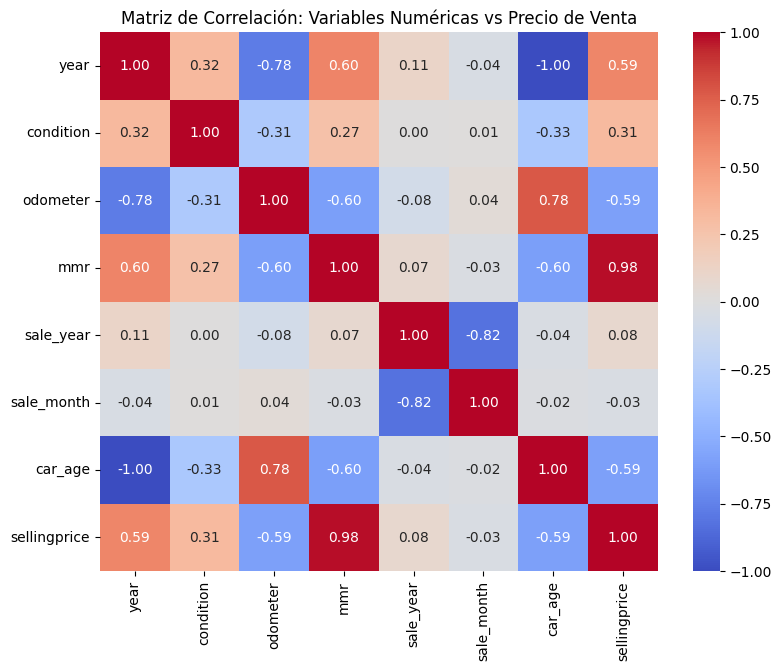

In [23]:
plt.figure(figsize=(9, 7))
cols_correlacion = cols_a_escalar + ['sellingprice']
corr_matrix = df_finale_scaled[cols_correlacion].corr()
sb.heatmap(corr_matrix, vmin=-1, vmax=1, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación: Variables Numéricas vs Precio de Venta")
plt.show()

El `mmr` se relaciona muy fuerte con el precio de venta (lógico, porque es el precio de referencia del mercado). También se ve que la antigüedad (`car_age`) y el kilometraje (`odometer`) se relacionan al revés con el precio: mientras más viejo y más kilómetros tiene el auto, más barato.

# 5. MODELO 1 — REGRESIÓN LINEAL MÚLTIPLE (método predictivo)

In [24]:
# Separar características (X) y la variable objetivo (y)
X = df_finale_scaled.drop(columns=['sellingprice'])
y = df_finale_scaled['sellingprice']

##  ¿Por qué separamos los datos en 80% y 20%? ¿Y qué es la validación cruzada?

Para evaluar un modelo se separan los datos: el 80% sirve para entrenarlo y el 20% restante se guarda aparte para probarlo, como rendir un examen con ejercicios distintos a los que estudiaste. Así se distingue si el modelo aprendió de verdad o solo memorizó.

El problema es que, hecho una sola vez, el resultado depende de qué casos cayeron en ese 20%: si fueron muy fáciles o muy difíciles, la nota engaña.

**Validación cruzada:** La validación cruzada soluciona esto dividiendo los datos en 5 partes y repitiendo la prueba 5 veces, usando cada vez 4 partes para entrenar y 1 para probar (rotando cuál se prueba). El promedio de esas 5 notas da una medida mucho más confiable del rendimiento real.

In [25]:
# Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Entrenamiento: {X_train.shape[0]} filas (80%)")
print(f"Prueba:        {X_test.shape[0]} filas (20%)")

Entrenamiento: 40000 filas (80%)
Prueba:        10000 filas (20%)


###  Entrenar y evaluar con la separación 80/20

In [26]:
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)          # El modelo aprende con el 80% de los datos
y_pred_lr = modelo_lr.predict(X_test)    # El modelo predice sobre el 20% de prueba

# Métricas específicas de regresión
mae_lr  = mean_absolute_error(y_test, y_pred_lr)   # En promedio, cuántos dólares se equivoca el modelo por auto
mse_lr  = mean_squared_error(y_test, y_pred_lr)    # Castiga más fuerte los errores grandes
rmse_lr = np.sqrt(mse_lr)                          # El error típico, ya de vuelta en dólares
r2_lr   = r2_score(y_test, y_pred_lr)              # Qué tan bien le acierta el modelo al precio (1 = perfecto)

print("--- RESULTADOS REGRESIÓN LINEAL (prueba con el 20%) ---")
print(f"Error Absoluto Medio (MAE):           US$ {mae_lr:,.2f}")
print(f"Error Cuadrático Medio (MSE):         {mse_lr:,.2f}")
print(f"Raíz del Error Cuadrático (RMSE):     US$ {rmse_lr:,.2f}")
print(f"Coeficiente de Determinación (R²):    {r2_lr:.4f}")

--- RESULTADOS REGRESIÓN LINEAL (prueba con el 20%) ---
Error Absoluto Medio (MAE):           US$ 1,024.94
Error Cuadrático Medio (MSE):         2,504,680.11
Raíz del Error Cuadrático (RMSE):     US$ 1,582.62
Coeficiente de Determinación (R²):    0.9745


###  Validación cruzada (5 partes)

In [27]:
# Partimos los datos en 5 partes iguales, mezclándolos primero
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Calculamos la nota (R²) y el error (MAE) en cada una de las 5 vueltas
r2_cv  = cross_val_score(modelo_lr, X, y, cv=kf, scoring='r2')
mae_cv = -cross_val_score(modelo_lr, X, y, cv=kf, scoring='neg_mean_absolute_error')

print("--- VALIDACIÓN CRUZADA (5 particiones) ---")
print(f"R²  por partición: {np.round(r2_cv, 4)}")
print(f"R²  PROMEDIO:      {r2_cv.mean():.4f}  (desv. estándar +/- {r2_cv.std():.4f})")
print(f"MAE PROMEDIO:      US$ {mae_cv.mean():,.2f}")

--- VALIDACIÓN CRUZADA (5 particiones) ---
R²  por partición: [0.9745 0.97   0.9693 0.971  0.9678]
R²  PROMEDIO:      0.9705  (desv. estándar +/- 0.0022)
MAE PROMEDIO:      US$ 1,042.16


El **R² promedio** de la validación cruzada confirma el resultado de la separación 80/20, y como las 5 notas salieron muy parecidas entre sí, sabemos que el modelo es **estable**: funciona parecido sin importar qué autos le toquen de prueba. Sacar el promedio de las 5 vueltas nos da el resultado más confiable.

### Gráfico 1: Valores Reales vs. Predicciones

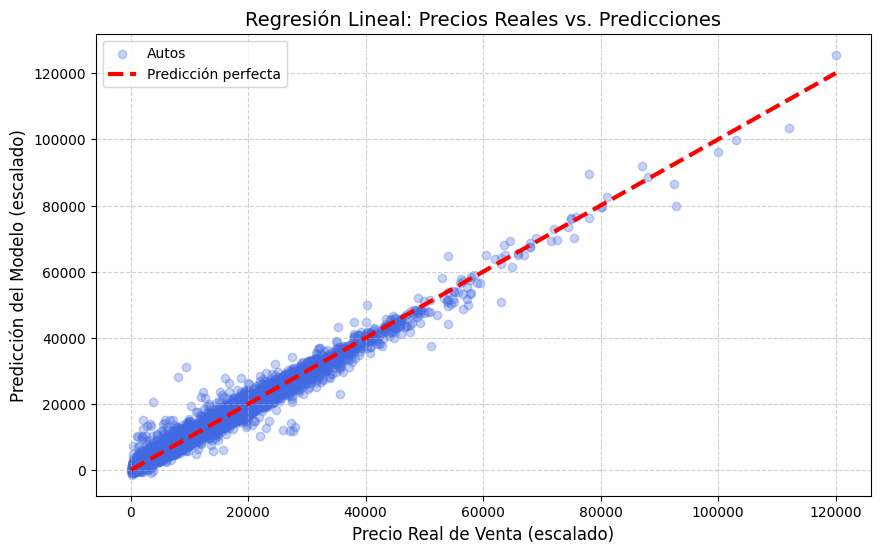

In [28]:
plt.figure(figsize=(10, 6))
# Puntos azules: cada auto (precio real vs precio predicho)
plt.scatter(y_test, y_pred_lr, alpha=0.3, color='royalblue', label='Autos')
# Línea roja: predicción perfecta (donde real = predicho)
rango_precios = [y_test.min(), y_test.max()]
plt.plot(rango_precios, rango_precios, 'r--', lw=3, label='Predicción perfecta')

plt.xlabel('Precio Real de Venta (escalado)', fontsize=12)
plt.ylabel('Predicción del Modelo (escalado)', fontsize=12)
plt.title('Regresión Lineal: Precios Reales vs. Predicciones', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Gráfico 2: Distribución de los Errores (Residuos)

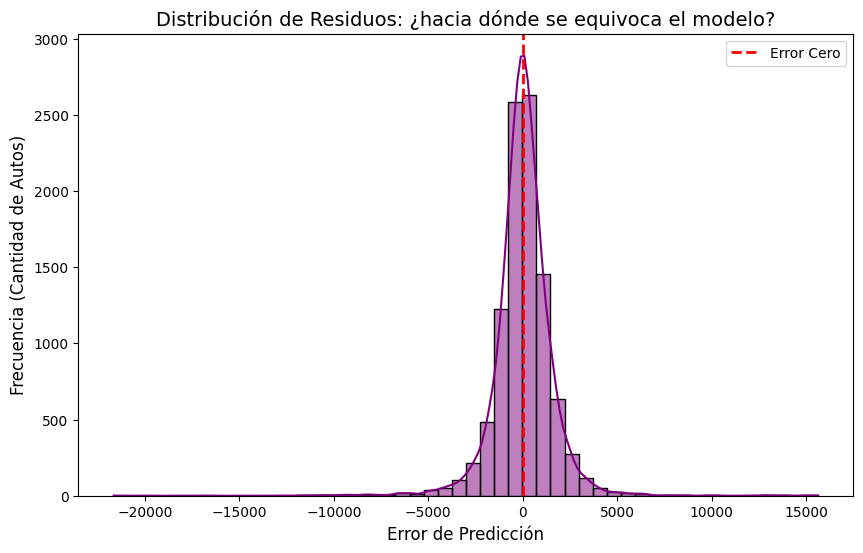

In [29]:
# En cuánto se equivocó el modelo en cada auto
errores = y_test - y_pred_lr

plt.figure(figsize=(10, 6))
sb.histplot(errores, bins=50, kde=True, color='purple')
plt.axvline(x=0, color='red', linestyle='--', lw=2, label='Error Cero')
plt.xlabel('Error de Predicción', fontsize=12)
plt.ylabel('Frecuencia (Cantidad de Autos)', fontsize=12)
plt.title('Distribución de Residuos: ¿hacia dónde se equivoca el modelo?', fontsize=14)
plt.legend()
plt.show()

Los errores se juntan alrededor del **cero** y forman una campana, lo que significa que el modelo **no se equivoca siempre para el mismo lado**: a veces calcula un poco de más y a veces un poco de menos, pero de forma pareja.

# 6. MODELO 2 — K-MEANS (agrupar autos parecidos)

La regresión de antes predecía un número (el precio): nosotros le decíamos qué adivinar. **K-means** funciona distinto: no le damos ninguna respuesta para adivinar. Su trabajo es **encontrar solo los grupos de autos parecidos** entre sí, mirando qué tan cerca o lejos están unos de otros según sus características. Sirve para **separar el mercado en distintos tipos de auto**.

##  Qué columnas usamos para agrupar
Para armar los grupos usamos las columnas de números que mejor describen un auto y su valor: año, estado, kilometraje, precio de mercado (MMR) y antigüedad. Usamos las versiones **ya emparejadas en escala** del paso anterior, porque K-means mide distancias y necesita que todas las columnas estén en la misma escala.

In [30]:
# Seleccionamos las variables numéricas escaladas para el clustering
features_cluster = ['year', 'condition', 'odometer', 'mmr', 'car_age']
X_cluster = df_finale_scaled[features_cluster]
print("Datos para clustering:", X_cluster.shape)

Datos para clustering: (50000, 5)


##  ¿En cuántos grupos dividimos? (Método del Codo + Silhouette)

K-means necesita que le digamos en cuántos grupos dividir. Para elegir bien ese número usamos dos ayudas:
- **Método del codo:** mide qué tan apretados quedan los autos dentro de cada grupo. Buscamos el "codo" en el gráfico, el punto donde sumar más grupos ya casi no mejora nada.
- **Silhouette Score:** es un puntaje (de -1 a 1, mientras más alto mejor) que mide qué tan bien separados y definidos quedaron los grupos. Es nuestra forma de medir si K-means quedó bien.

In [31]:
# Probamos con distinta cantidad de grupos y medimos qué tan bien quedan
inercias, silhouettes = [], []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster, labels, sample_size=10000, random_state=42))
    print(f"k={k}:  inercia={km.inertia_:>10.1f}   silhouette={silhouettes[-1]:.4f}")

k=2:  inercia=  126032.2   silhouette=0.4650
k=3:  inercia=  101284.2   silhouette=0.4165
k=4:  inercia=   82606.1   silhouette=0.3726
k=5:  inercia=   68619.9   silhouette=0.3289
k=6:  inercia=   62102.5   silhouette=0.3032
k=7:  inercia=   56938.3   silhouette=0.2762
k=8:  inercia=   52873.8   silhouette=0.2791


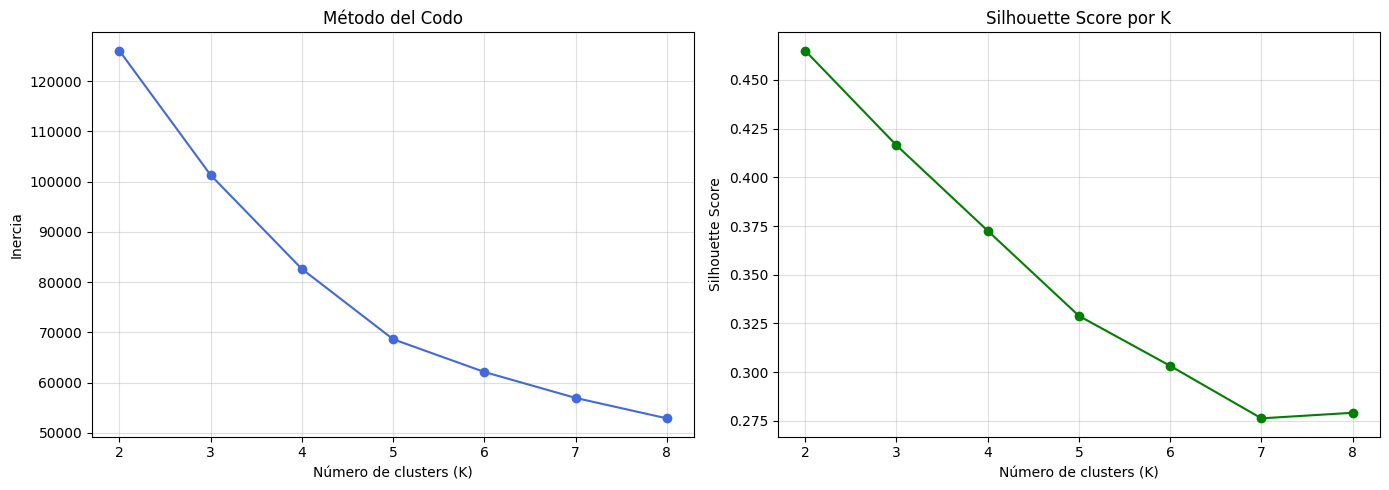

In [32]:
# Graficamos ambos criterios lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(K_range), inercias, 'o-', color='royalblue')
ax1.set_xlabel('Número de clusters (K)'); ax1.set_ylabel('Inercia')
ax1.set_title('Método del Codo'); ax1.grid(True, alpha=0.4)

ax2.plot(list(K_range), silhouettes, 'o-', color='green')
ax2.set_xlabel('Número de clusters (K)'); ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score por K'); ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

Mirando el codo y el silhouette, elegimos **4 grupos**: es un buen equilibrio entre grupos bien separados y una división que tiene sentido para entender el mercado.

In [33]:
# Entrenamos K-means con el K elegido
K_OPT = 4
kmeans = KMeans(n_clusters=K_OPT, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_cluster)

# Guardamos la etiqueta de cluster en el dataframe limpio (valores reales, sin escalar)
df_clusters = df_limpio.loc[X_cluster.index].copy()
df_clusters['cluster'] = clusters

# MÉTRICA de evaluación del modelo
sil_final = silhouette_score(X_cluster, clusters, sample_size=10000, random_state=42)
print(f"K-means con K={K_OPT}")
print(f"Silhouette Score: {sil_final:.4f}")

K-means con K=4
Silhouette Score: 0.3726


##  Qué tipo de auto representa cada grupo
Sacamos los promedios reales de cada grupo para entender qué clase de auto cayó en cada uno.

In [34]:
# Perfil promedio de cada cluster (en valores reales, fáciles de interpretar)
perfil = df_clusters.groupby('cluster')[
    ['year', 'car_age', 'odometer', 'condition', 'mmr', 'sellingprice']
].mean().round(0)
perfil['cantidad_autos'] = df_clusters.groupby('cluster').size()
perfil

,year,car_age,odometer,condition,mmr,sellingprice,cantidad_autos
cluster,,,,,,,
0,2003.0,12.0,152366.0,20.0,3042.0,2890.0,7368
1,2013.0,2.0,33517.0,7.0,18022.0,17035.0,5065
2,2013.0,2.0,35758.0,39.0,18522.0,18502.0,25361
3,2008.0,7.0,98857.0,30.0,8540.0,8440.0,12206


Cada grupo es un **tipo de auto distinto** dentro del mercado:
- Autos **nuevos y caros**: pocos años, poco kilometraje, precio alto.
- Autos **baratos y viejos**: muchos años, mucho kilometraje, precio bajo.
- Grupos **intermedios**, con mezclas entre antigüedad y kilometraje.

Esta división ayuda a **tomar decisiones**: por ejemplo, manejar precios o inventario distintos para cada tipo de auto.

### Visualización de los clusters

Usamos 5 columnas para agrupar, y no se pueden dibujar 5 cosas a la vez en un gráfico plano. Con **PCA** resumimos esas 5 columnas en solo 2, sin perder mucha información, para poder ver en un gráfico cómo quedaron separados los grupos.

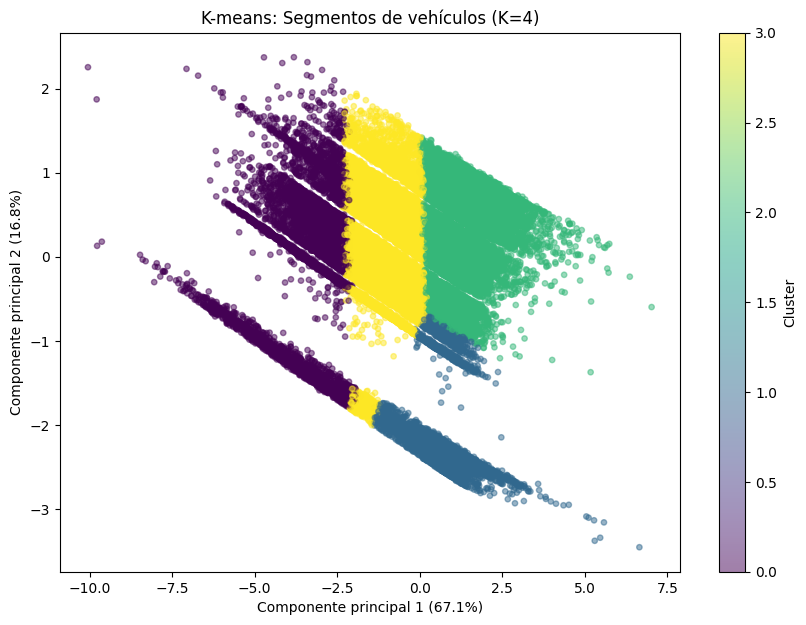

Las 2 componentes explican el 83.9% de la varianza.


In [35]:
# Resumimos las 5 columnas en 2 solo para poder dibujarlas
pca = PCA(n_components=2)
coords = pca.fit_transform(X_cluster)

plt.figure(figsize=(10, 7))
sc = plt.scatter(coords[:, 0], coords[:, 1], c=clusters, cmap='viridis', alpha=0.5, s=15)
plt.colorbar(sc, label='Cluster')
plt.xlabel(f'Componente principal 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Componente principal 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title(f'K-means: Segmentos de vehículos (K={K_OPT})')
plt.show()

print(f"Las 2 componentes explican el {pca.explained_variance_ratio_[:2].sum()*100:.1f}% de la varianza.")

### Distribución de precios por cluster

/tmp/ipykernel_2511/2254479718.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(data=df_clusters, x='cluster', y='sellingprice', palette='viridis')


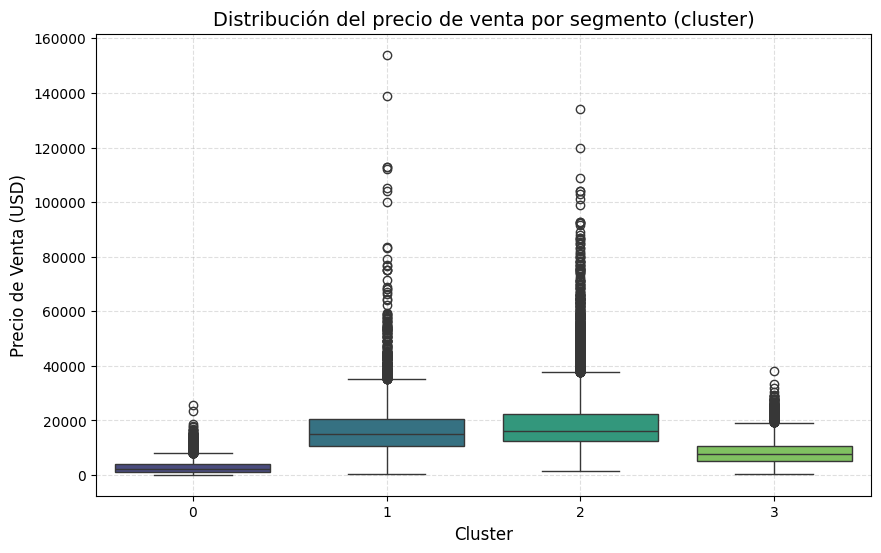

In [36]:
plt.figure(figsize=(10, 6))
sb.boxplot(data=df_clusters, x='cluster', y='sellingprice', palette='viridis')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Precio de Venta (USD)', fontsize=12)
plt.title('Distribución del precio de venta por segmento (cluster)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

El gráfico de cajas confirma que los grupos **separan bien los rangos de precio**, lo que muestra que la división tiene sentido.

# 7. SET DE DATOS DE PRUEBA

Acá evaluamos el modelo de precios con el 20% de autos que separamos al principio (autos que el modelo nunca vio mientras aprendía). Esto confirma que el modelo funciona también con autos "nuevos", no solo con los que usó para entrenar.

In [37]:
# Evaluación final sobre el set de prueba (20% reservado)
y_pred_test = modelo_lr.predict(X_test)

print("===== EVALUACIÓN SOBRE EL SET DE DATOS DE PRUEBA (20%) =====")
print(f"Cantidad de autos en prueba:      {len(X_test):,}")
print(f"MAE  (error promedio):            US$ {mean_absolute_error(y_test, y_pred_test):,.2f}")
print(f"RMSE (error típico):              US$ {np.sqrt(mean_squared_error(y_test, y_pred_test)):,.2f}")
print(f"R²   (capacidad explicativa):     {r2_score(y_test, y_pred_test):.4f}")

# Comparación de algunos casos reales vs predichos
comparacion = pd.DataFrame({
    'precio_real': y_test.values[:10],
    'precio_predicho': y_pred_test[:10]
}).round(3)
print("\nEjemplos (valores reales en USD):")
print(comparacion)

===== EVALUACIÓN SOBRE EL SET DE DATOS DE PRUEBA (20%) =====
Cantidad de autos en prueba:      10,000
MAE  (error promedio):            US$ 1,024.94
RMSE (error típico):              US$ 1,582.62
R²   (capacidad explicativa):     0.9745

Ejemplos (valores reales en USD):
   precio_real  precio_predicho
0       3800.0         2632.276
1      19200.0        19394.332
2      35400.0        33176.203
3       6300.0         6821.100
4       9600.0        10619.259
5      21900.0        20438.102
6      16100.0        16573.182
7       1500.0         1184.909
8      19000.0        19243.064
9       2600.0          888.665


# 8. Guardar el modelo en un archivo `.PKL`

Guardamos el modelo ya entrenado en un solo archivo `.pkl`. Con esto, el modelo se puede meter después en una página web, un formulario o una app para que prediga precios, sin tener que entrenarlo de nuevo cada vez.

In [38]:
# Empaquetamos modelo + transformadores en un solo archivo
paquete_modelo = {
    'modelo': modelo_lr,
    'scaler': scaler,
    'ohe': ohe,
    'var_numericas': var_numericas,
    'var_categoricas': var_categoricas,
    'columnas_X': list(X.columns)
}
joblib.dump(paquete_modelo, 'modelo_precio_autos.pkl')
print("Modelo guardado en 'modelo_precio_autos.pkl'")

Modelo guardado en 'modelo_precio_autos.pkl'


**Carga de el modelo**

In [39]:
# Así se cargaría y usaría el modelo en producción (Flask, formulario, etc.)
paquete = joblib.load('modelo_precio_autos.pkl')
modelo_cargado = paquete['modelo']

# Predecimos sobre los primeros autos del set de prueba como demostración
demo_pred = modelo_cargado.predict(X_test[:5])
print("Predicciones del modelo cargado desde .pkl:")
print(np.round(demo_pred, 3))

Predicciones del modelo cargado desde .pkl:
[ 2632.276 19394.332 33176.203  6821.1   10619.259]


**Pagina Web PKL:** https://app-precio-autos.vercel.app/

# 9. Dejar los resultados listos para el Panel (Data Studio / Power BI)

Creamos un archivo CSV con los resultados de nuestros modelos (el precio que predijo y a qué grupo quedó cada auto). Este archivo es el que vamos a **conectar a Looker Studio o Power BI** para armar el panel de gráficos que ayuda a tomar decisiones.

In [40]:
# Construimos el dataset de resultados para el dashboard
resultados = df_clusters.copy()

# Agregamos la predicción de precio del modelo de regresión a cada auto
resultados['precio_predicho'] = modelo_lr.predict(X)
resultados['error_prediccion'] = resultados['sellingprice'] - resultados['precio_predicho']

# Renombramos el cluster a una etiqueta más clara para el panel
resultados['segmento'] = 'Segmento ' + resultados['cluster'].astype(str)

# Exportamos a CSV
resultados.to_csv('resultados_para_dashboard.csv', index=False)
print("Archivo 'resultados_para_dashboard.csv' generado.")
print("Columnas disponibles para el panel:")
print(list(resultados.columns))
resultados.head()

Archivo 'resultados_para_dashboard.csv' generado.
Columnas disponibles para el panel:
['year', 'make', 'model', 'body', 'transmission', 'state', 'condition', 'odometer', 'color', 'interior', 'mmr', 'sale_year', 'sale_month', 'car_age', 'sellingprice', 'cluster', 'precio_predicho', 'error_prediccion', 'segmento']


,year,make,model,body,transmission,state,condition,odometer,color,interior,mmr,sale_year,sale_month,car_age,sellingprice,cluster,precio_predicho,error_prediccion,segmento
0,2014,chevrolet,otros,sedan,automatic,fl,4.0,21507.0,white,black,13450.0,2015.0,2.0,1.0,13800.0,1,12333.662480,1466.337520,Segmento 1
1,2003,dodge,otros,quad cab,no_disponible,mo,31.0,79712.0,—,black,6025.0,2015.0,1.0,12.0,6300.0,0,6622.008027,-322.008027,Segmento 0
2,2007,otros,otros,convertible,automatic,nj,34.0,65698.0,red,black,7375.0,2015.0,1.0,8.0,8000.0,3,7358.977327,641.022673,Segmento 3
3,2011,toyota,corolla,sedan,automatic,fl,43.0,23634.0,black,beige,10800.0,2015.0,1.0,4.0,11400.0,2,11364.157499,35.842501,Segmento 2
4,2012,lexus,otros,sedan,no_disponible,pa,35.0,26483.0,black,brown,22500.0,2015.0,1.0,3.0,23300.0,2,22357.077954,942.922046,Segmento 2



**Google Data Studio:**
https://datastudio.google.com/u/5/reporting/bb00323f-bc5e-42ab-8ce1-e64c619e4ab7/page/WJG2F

# 10. Conclusiones

**Sobre los modelos:**
- El modelo de **regresión** predice el precio de venta con muy buena puntería (lo confirmamos con la separación 80/20 y con la validación cruzada), y como las notas salieron parecidas en cada vuelta, es un modelo **estable**. La columna que más influye en el precio es el `mmr` (el precio de referencia del mercado).
- El modelo **K-means** encontró **grupos de autos** bien diferenciados según su antigüedad, kilometraje y precio, lo que nos da una mirada del mercado que la regresión sola no entrega.